# Технологии машинного обучения
### РК1 - Артём Смирнов ИУ5-63Б
### Вариант 16 - Задача №2, Набор данных №8

**Задание:** 

Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?  

Для произвольной колонки данных построить график "Ящик с усами (boxplot)".

#### Импортируем библиотеки

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Импортируем данные

- **CRIM** – уровень преступности на душу населения по городам.  
- **ZN** – доля жилых зон, отведённых под участки площадью более 25 000 кв. футов.  
- **INDUS** – доля земель коммерческого назначения (не розничная торговля) в городе.  
- **CHAS** – фиктивная переменная реки Чарльз (=1, если участок прилегает к реке; 0 в противном случае).  
- **NOX** – концентрация оксидов азота (частей на 10 миллионов).  
- **RM** – среднее количество комнат в жилом помещении.  
- **AGE** – доля домов, построенных до 1940 года и занятых владельцами.  
- **DIS** – средневзвешенное расстояние до пяти рабочих центров Бостона.  
- **RAD** – индекс доступности радиальных магистралей.  
- **TAX** – ставка налога на недвижимость (полная стоимость на $10 000).  
- **PTRATIO** – соотношение учеников к учителям по городам.  
- **B** – расчётный показатель: `1000(Bk - 0.63)^2`, где **Bk** – доля чернокожего населения в городе.  
- **LSTAT** – процент населения с низким социально-экономическим статусом.  
- **MEDV** – медианная стоимость домов, занимаемых владельцами (в тысячах долларов).  


In [12]:
df = pd.read_csv('HousingData.csv')

### Основные характеристики датасета

In [13]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
# Размер датасета - 506 строк, 14 столбцов
df.shape 

(506, 14)

#### Проверим признаки на пропуски

In [21]:
print("Пропуски до обработки:")
print(df[['CHAS', 'LSTAT']].isnull().sum())

Пропуски до обработки:
CHAS     20
LSTAT    20
dtype: int64


#### Заполним пропуски 

In [ ]:
# Заполнение пропусков в CHAS (категориальный)
if df['CHAS'].isnull().sum() > 0:
    df.fillna({'CHAS': df['CHAS'].mode()[0]}, inplace=True)
    print("Пропуски в CHAS заполнены модой.")
else:
    print("Пропусков в CHAS нет.")

# Заполнение пропусков в LSTAT (количественный)
if df['AGE'].isnull().sum() > 0:
    df.fillna({'LSTAT': df['LSTAT'].median()}, inplace=True)
    print("Пропуски в LSTAT заполнены медианой.")
else:
    print("Пропусков в LSTAT нет.")

Пропуски в CHAS заполнены модой.
Пропуски в LSTAT заполнены медианой.


In [ ]:
# Проверка после обработки
print("\nПропуски после обработки:")
print(df[['CHAS', 'LSTAT']].isnull().sum())


Пропуски после обработки:
CHAS     0
LSTAT    0
dtype: int64


#### Построим диаграмму "Ящик с усами"

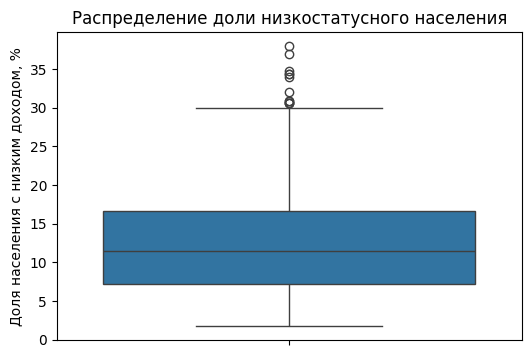

In [25]:
# Boxplot для RM
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y='LSTAT')
plt.title("Распределение доли низкостатусного населения")
plt.ylabel("Доля населения с низким доходом, %")
plt.show()

#### Для нахождения наиболее важных признаков для построения модели посмотрим корреляцию с целевой переменной

In [39]:
# Строим корреляционную матрицу
corr_matrix = df.corr()

print("\nКорреляция всех признаков с MEDV:")
print(corr_matrix['MEDV'].sort_values(ascending=False)[1:])



Корреляция всех признаков с MEDV:
RM         0.695360
ZN         0.373136
B          0.333461
DIS        0.249929
CHAS       0.183844
RAD       -0.381626
CRIM      -0.391363
AGE       -0.394656
NOX       -0.427321
TAX       -0.468536
INDUS     -0.481772
PTRATIO   -0.507787
LSTAT     -0.723093
Name: MEDV, dtype: float64
